# Self-Heal Loop with LangGraph

> A repair loop is safe only when every attempt is bounded, receipt-bound, and compensated before a non-success result escapes.


## What this pattern does

Self-Heal starts with a known failure, proposes one patch at a time, reviews it, applies it, and verifies the changed workspace. A passing verification commits the repaired state. Every other terminal path compensates newest-first and reports whether the original baseline was restored.

### Learning goals

By the end, you will be able to read a repair workflow as ordinary Python functions connected by deterministic control flow, identify which decisions belong to models and which belong to deterministic code, and follow the receipts that make rollback provable.

### Who owns each decision?

| Decision | Owner | Why |
|---|---|---|
| Diagnose a failure | Replaceable Python function, optionally model-backed | This is an interpretive task. |
| Draft a patch | Replaceable Python function, optionally model-backed | This is a generative task. |
| Review, apply, and verify | Deterministic Python functions | Safety policy and workspace evidence must not depend on model judgment. |
| Retry, stop, or roll back | Deterministic Python control flow | Bounds and compensation are transaction rules. |
| Declare the final status | Deterministic result-building step | The result must follow from receipts and digests. |

### Five safety invariants

1. Every run captures its own baseline before any repair role runs.
2. Diagnose, draft, review, and verify are observationally pure: they may not mutate managed state.
3. The same `(failure.signature, patch.digest)` pair is never applied twice.
4. Apply, verification, and rollback evidence must bind to the patch or commit it describes.
5. A non-success result proves restoration or becomes human handoff.

### Two paths to keep in mind

A successful run can take more than one round:

```text
success:
failure₁ -> patch₁/c1 -> verify failure₂ -> patch₂/c2 -> verify success
```

A later regression compensates in reverse apply order:

```text
compensation:
c1 -> c2 -> regression -> rollback c2 -> rollback c1 -> baseline restored
```


## LangGraph from basic Python

LangGraph does not replace Python functions. It gives those functions a shared state dictionary and a visible map of what may run next.

- A **graph** is a workflow.
- **State** is the dictionary carried between steps.
- A **node** is a Python function that reads state and returns a state update.
- An **edge** chooses which node runs next.
- A **conditional edge** chooses among named routes using current state.
- `START` and `END` are the workflow's entry and exit markers.
- `StateGraph(GraphState)` checks the expected shape of state for readers and tools.

If you know a loop containing `if` statements, you already know the basic control flow. Here, each stage is a function, each returned dictionary updates only the keys that changed, and a routing function returns a short route name such as `"verify"` or `"rollback"`. The graph builder connects that name to the next Python function.

### Compare the two implementations

The sibling notebook uses LangChain. There, a **runnable** is an object called with `.invoke(input)`, and **LCEL** is LangChain's syntax for composing runnables. With the vocabulary on both sides now defined, the implementations compare like this:

| | `langgraph/` (`StateGraph`) | [`langchain/`](../langchain/tutorial.ipynb) (LCEL) |
|---|---|---|
| Repair stages | Explicit nodes and conditional edges | Runnables around an explicit loop driver |
| Deterministic roles | Plain Python callables | Python callables adapted as runnables |
| Business bound | A maximum-round rule represented in graph state | The same maximum-round rule inside the transaction |
| Safety proof | Apply, verify, and rollback receipts plus state digests | The same receipt-and-digest proof |
| Trade-off | More code, every transition is inspectable | Less graph ceremony, loop orchestration stays in code |


## Setup

The deterministic section is fully offline. The setup searches upward for the pattern helpers and repository helpers, so execution works from the repository root, the notebook directory, `nbmake`, or JupyterLab without relying on `__file__` or a brittle relative path.


In [1]:
from __future__ import annotations

import html
import json
import sys
from dataclasses import replace
from pathlib import Path
from typing import Callable, Iterable, TypedDict

# Search upward for repository helpers so this works from Jupyter, nbmake,
# the notebook directory, or the repository root.
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / _marker).exists()
    )
    sys.path.insert(0, str(_dir))

# Notebook display, message, graph, and schema tools used by the tutorial.
from IPython.display import HTML, display  # noqa: E402
from IPython.utils.capture import capture_output  # noqa: E402
from langchain_core.messages import HumanMessage, SystemMessage  # noqa: E402
from langgraph.graph import END, START, StateGraph  # noqa: E402
from pydantic import BaseModel, ConfigDict, Field  # noqa: E402

# Repository modules supply model setup, domain records, fixtures, and parsers.
from model_config import get_model  # noqa: E402
from nbtools import show_graph  # noqa: E402
from pattern import (  # noqa: E402
    ApplyReceipt,
    FailureSignal,
    HealRound,
    HealStage,
    HealStatus,
    HealTrace,
    Patch,
    PatchReview,
    RollbackReceipt,
    StageError,
    VerificationReceipt,
)
from shared import (  # noqa: E402
    RECORD_FIELDS,
    SCENARIO_ORDER,
    format_scenario_matrix,
    format_scenario_walkthrough,
    ScenarioRuntime,
    assert_expected_record,
    new_runtime,
    parse_diagnosis_json,
    parse_patch_json,
    run_core_reference,
    trace_record,
)

## Transaction state

`GraphState` is a `TypedDict`: at runtime it is still a normal Python dictionary. The annotation documents which keys may appear. `total=False` matters because each node returns only the keys it changes rather than rebuilding the whole transaction.

Mutable collections are created by `capture_baseline` for each invocation; no run shares attempts, receipts, or errors with another. The seven deterministic scenarios run in this locked order: `convergence`, `critic_block`, `no_progress`, `regression`, `round_budget`, `stage_error`, and `rollback_failure`.


In [2]:
# Nodes read this shared dictionary and return only changed keys. LangGraph
# merges each partial update into the state already carried by the graph.
class GraphState(TypedDict, total=False):
    # Invocation inputs: supplied once by the caller.
    runtime: ScenarioRuntime
    diagnose_role: Callable[[FailureSignal], str]
    draft_role: Callable[[str], Patch]
    initial_failure: FailureSignal
    # Current round: replaced as the transaction advances.
    current_failure: FailureSignal
    baseline_digest: str
    round_no: int
    diagnosis: str
    patch: Patch
    attempt_keys: set[tuple[str, str]]
    commit_ids: set[str]
    radius_files: set[str]
    rounds: list[HealRound]
    # Receipt evidence: append-only proof of mutation and verification.
    apply_receipts: list[ApplyReceipt]
    rollback_receipts: list[RollbackReceipt]
    stage_errors: list[StageError]
    # Compensation proof and terminal result.
    status: HealStatus
    stop_reason: str
    final_digest: str | None
    baseline_restored: bool | None
    unaddressable_mutation: bool
    next_route: str
    trace: HealTrace


## Build the graph

We will define the workflow in small explain-then-code pairs. The main path is:

`START -> capture_baseline -> diagnose -> draft_patch -> duplicate_guard -> review -> apply -> verify -> decide`

`decide` may finish, begin another bounded round, or compensate. Any error or non-success stop routes through `rollback` before `finalize`.

Before the nodes, three helper groups establish the evidence rules they share.

### Digest reads and public stage errors

A digest is a compact fingerprint of workspace state. These helpers validate digest reads and convert callback exceptions into stable `StageError` evidence.


In [3]:
# A digest observes managed workspace state without changing it; later checks
# use the value to detect hidden mutation or prove restoration.
def _read_digest(runtime: ScenarioRuntime) -> str:
    digest = runtime.workspace.state_digest()
    if not isinstance(digest, str) or not digest.strip():
        raise ValueError("state_digest must be a nonblank string")
    return digest


# Extract only expected fields instead of storing an entire callback object.
def _receipt_evidence(receipt: object, fields: Iterable[str]) -> tuple[str, ...]:
    return tuple(f"{name}={getattr(receipt, name, '<missing>')!r}" for name in fields)


# StageError is the public error record and keeps at most eight evidence fields.
def _stage_error(
    stage: HealStage,
    round_no: int | None,
    exc: BaseException,
    evidence: Iterable[str] = (),
) -> StageError:
    values = tuple(
        value for value in evidence if isinstance(value, str) and value.strip()
    )[:8]
    return StageError(
        stage,
        round_no,
        type(exc).__name__,
        str(exc) or repr(exc),
        values,
    )


# Turn digest callback failures into state so routing can handle them
# instead of raising out of the transaction.
def _digest_or_error(
    runtime: ScenarioRuntime,
    round_no: int | None,
) -> tuple[str | None, list[StageError]]:
    try:
        return _read_digest(runtime), []
    except Exception as exc:  # the runtime owns the state callback
        return None, [_stage_error(HealStage.STATE_CHECK, round_no, exc)]

### Pure-role guard

A role may calculate a value, but it may not quietly change the workspace. `_pure_role` reads the digest before and after a callback and reports both ordinary exceptions and forbidden mutation.


In [4]:
# Invariant: a pure role must not mutate managed workspace state.
def _pure_role(
    runtime: ScenarioRuntime,
    stage: HealStage,
    round_no: int,
    callback: Callable[..., object],
    *args: object,
) -> tuple[object | None, bool, bool, list[StageError]]:
    # Capture the workspace fingerprint before the observational callback runs.
    before, errors = _digest_or_error(runtime, round_no)
    if before is None:
        return None, False, False, errors
    try:
        result = callback(*args)
    except Exception as exc:
        errors.append(_stage_error(stage, round_no, exc))
        # A callback that raises may still have changed state, so measure again.
        after, digest_errors = _digest_or_error(runtime, round_no)
        errors.extend(digest_errors)
        mutated = after is not None and after != before
        if mutated:
            errors.append(
                _stage_error(
                    stage,
                    round_no,
                    RuntimeError("callback mutated managed state"),
                    (f"before_digest={before!r}", f"after_digest={after!r}"),
                )
            )
        return None, mutated, False, errors
    # A normal return is accepted only when the after digest matches the before digest.
    after, digest_errors = _digest_or_error(runtime, round_no)
    errors.extend(digest_errors)
    if after is None:
        return result, False, False, errors
    if after != before:
        errors.append(
            _stage_error(
                stage,
                round_no,
                RuntimeError("callback mutated managed state"),
            )
        )
        return result, True, False, errors
    return result, False, True, errors

### Receipt validators

Receipts are useful only when they describe the exact patch or commit in this transaction. These pure helpers validate that binding without mutating graph state.


In [5]:
# A typed, evidence-bearing review is valid only when it names this patch.
def _validate_review(receipt: object, patch: Patch) -> tuple[bool, tuple[str, ...]]:
    fields = ("patch_digest", "approved", "reason", "evidence")
    if not isinstance(receipt, PatchReview):
        return False, _receipt_evidence(receipt, fields)
    valid = (
        receipt.patch_digest == patch.digest
        and type(receipt.approved) is bool
        and isinstance(receipt.evidence, tuple)
        and any(
            isinstance(item, str) and item.strip()
            for item in receipt.evidence
        )
        and (
            receipt.approved
            or (isinstance(receipt.reason, str) and receipt.reason.strip())
        )
    )
    return valid, _receipt_evidence(receipt, fields)


# "addressable" means rollback can name a unique commit. "valid" also binds
# that commit to the patch digest and exactly the files the patch declares.
def _validate_apply(
    receipt: object,
    patch: Patch,
    seen: set[str],
) -> tuple[bool, bool, tuple[str, ...]]:
    fields = ("commit_id", "patch_digest", "changed_files")
    if not isinstance(receipt, ApplyReceipt):
        return False, False, _receipt_evidence(receipt, fields)
    addressable = (
        isinstance(receipt.commit_id, str)
        and bool(receipt.commit_id.strip())
        and receipt.commit_id not in seen
    )
    valid = (
        addressable
        and receipt.patch_digest == patch.digest
        and receipt.changed_files == patch.touches
    )
    return valid, addressable, _receipt_evidence(receipt, fields)


# Rebuilding the value reruns FailureSignal validation and catches malformed
# instances that still pass isinstance().
def _valid_failure_signal(value: object) -> bool:
    if not isinstance(value, FailureSignal):
        return False
    try:
        normalized = FailureSignal(
            value.kind,
            value.error_text,
            value.affected_files,
            value.code,
        )
    except (TypeError, ValueError):
        return False
    return (
        value.kind == normalized.kind
        and value.error_text == normalized.error_text
        and value.affected_files == normalized.affected_files
        and value.code == normalized.code
    )


# Verification must name the exact apply receipt; a reported failure must
# also be a valid FailureSignal for the next round.
def _validate_verify(
    receipt: object,
    applied: ApplyReceipt,
) -> tuple[bool, tuple[str, ...]]:
    fields = ("commit_id", "patch_digest", "failure", "check", "evidence")
    if not isinstance(receipt, VerificationReceipt):
        return False, _receipt_evidence(receipt, fields)
    valid = (
        receipt.commit_id == applied.commit_id
        and receipt.patch_digest == applied.patch_digest
        and (receipt.failure is None or _valid_failure_signal(receipt.failure))
        and isinstance(receipt.check, str)
        and bool(receipt.check.strip())
        and isinstance(receipt.evidence, str)
        and bool(receipt.evidence.strip())
    )
    return valid, _receipt_evidence(receipt, fields)

### Capture the baseline

**Input:** The caller-supplied runtime, initial failure, and role callables.

**Purpose:** Initialize fresh transaction collections and record the pre-repair workspace digest.

**Invariant:** No repair role runs before a valid baseline exists, and caller input is validated before its affected-file radius enters graph state.

**Failure route:** A failed digest read goes directly to `finalize`. A malformed initial failure becomes a stable diagnose-stage error and also finalizes without calling a role, apply, or rollback callback.


In [6]:
def capture_baseline(state: GraphState) -> dict[str, object]:
    # No repair role or mutating callback may run until a baseline digest exists.
    baseline, errors = _digest_or_error(state["runtime"], None)
    # Start with an empty radius: caller data enters it only after full validation.
    initial: dict[str, object] = {
        "round_no": 1,
        "attempt_keys": set(),
        "commit_ids": set(),
        "radius_files": set(),
        "rounds": [],
        "apply_receipts": [],
        "rollback_receipts": [],
        "stage_errors": errors,
        "unaddressable_mutation": False,
    }
    # Baseline failure happens before apply, so rollback has no known work to undo.
    if baseline is None:
        return {
            **initial,
            "status": HealStatus.STAGE_ERROR_HUMAN_HANDOFF,
            "stop_reason": "stage_error:state_check",
            "final_digest": None,
            "baseline_restored": None,
            "next_route": "finalize",
        }

    failure = state.get("initial_failure")
    if not _valid_failure_signal(failure):
        # Rebuild-based validation catches both wrong types and forged dataclasses.
        input_error = _stage_error(
            HealStage.DIAGNOSE,
            None,
            TypeError("failure must be a valid FailureSignal"),
        )
        final, final_errors = _digest_or_error(state["runtime"], None)
        all_errors = [*errors, input_error, *final_errors]
        restored = final is not None and final == baseline
        return {
            **initial,
            "stage_errors": all_errors,
            "baseline_digest": baseline,
            "final_digest": final,
            "baseline_restored": restored,
            "status": (
                HealStatus.STAGE_ERROR_HUMAN_HANDOFF
                if restored
                else HealStatus.ROLLBACK_FAILED_HUMAN_HANDOFF
            ),
            "stop_reason": "stage_error:diagnose",
            "next_route": "finalize",
        }

    # Only validated paths may define the deterministic repair radius.
    initial["radius_files"] = set(failure.affected_files)
    # LangGraph merges this partial update with caller inputs such as runtime
    # and the role callables.
    return {
        **initial,
        "baseline_digest": baseline,
        "current_failure": failure,
        "next_route": "diagnose",
    }


# A route function returns a name; graph assembly later maps it to a node.
def route_after_capture(state: GraphState) -> str:
    return state["next_route"]

### Diagnose the current failure

**Input:** The current `FailureSignal` and `diagnose_role` callable.

**Purpose:** Produce one nonblank diagnosis for the current round.

**Invariant:** Diagnosis is observationally pure and must return a nonblank `str`.

**Failure route:** Callback, type, digest, or mutation failure routes to `rollback` through `_role_failure`.


In [7]:
# Convert a stage failure into shared state before routing through rollback.
def _role_failure(
    state: GraphState,
    stage: HealStage,
    errors: list[StageError],
    mutated: bool,
) -> dict[str, object]:
    last_stage = errors[-1].stage if errors else stage
    return {
        "stage_errors": [*state["stage_errors"], *errors],
        "unaddressable_mutation": state["unaddressable_mutation"] or mutated,
        "status": HealStatus.STAGE_ERROR_HUMAN_HANDOFF,
        "stop_reason": f"stage_error:{last_stage.value}",
        "next_route": "rollback",
    }


def diagnose(state: GraphState) -> dict[str, object]:
    # _pure_role returns both the proposal and evidence that no mutation occurred.
    result, mutated, ok, errors = _pure_role(
        state["runtime"],
        HealStage.DIAGNOSE,
        state["round_no"],
        state["diagnose_role"],
        state["current_failure"],
    )
    # Deterministic Python checks type and content; the role cannot declare
    # an empty string useful merely by returning the expected Python type.
    if ok and (not isinstance(result, str) or not result.strip()):
        error = (
            TypeError("diagnose must return str")
            if not isinstance(result, str)
            else ValueError("diagnose must return a nonblank string")
        )
        errors.append(_stage_error(HealStage.DIAGNOSE, state["round_no"], error))
        ok = False
    if not ok:
        return _role_failure(state, HealStage.DIAGNOSE, errors, mutated)
    # Only diagnosis and the next route change; every other state key remains.
    return {"diagnosis": result, "next_route": "draft_patch"}


def route_after_diagnose(state: GraphState) -> str:
    return state["next_route"]

### Draft one patch

**Input:** The diagnosis and `draft_role` callable.

**Purpose:** Create the round's candidate `Patch` and append its `HealRound` evidence.

**Invariant:** Drafting is observationally pure and must return `Patch`.

**Failure route:** Callback, type, digest, or mutation failure routes to `rollback`.


In [8]:
def draft_patch(state: GraphState) -> dict[str, object]:
    # Drafting reuses the purity guard: the role may propose a Patch only.
    result, mutated, ok, errors = _pure_role(
        state["runtime"],
        HealStage.FIX,
        state["round_no"],
        state["draft_role"],
        state["diagnosis"],
    )
    if ok and not isinstance(result, Patch):
        errors.append(
            _stage_error(
                HealStage.FIX,
                state["round_no"],
                TypeError("fix must return Patch"),
            )
        )
        ok = False
    if not ok:
        return _role_failure(state, HealStage.FIX, errors, mutated)
    patch = result
    # Start this round's evidence record before review or workspace mutation.
    round_ = HealRound(
        state["round_no"],
        state["current_failure"],
        state["diagnosis"],
        patch,
    )
    return {
        "patch": patch,
        "rounds": [*state["rounds"], round_],
        "next_route": "duplicate_guard",
    }


def route_after_draft(state: GraphState) -> str:
    return state["next_route"]

### Reject duplicate work

**Input:** The current failure signature, patch digest, and prior attempt keys.

**Purpose:** Stop a loop that proposes the same patch for the same failure twice.

**Invariant:** A repeated failure-and-patch pair is never applied again.

**Failure route:** A duplicate routes to `rollback` with `no_progress_same_failure_and_patch`.


In [9]:
# Invariant: the same failure and patch pair may never be applied twice.
def duplicate_guard(state: GraphState) -> dict[str, object]:
    attempt = (state["current_failure"].signature, state["patch"].digest)
    # Copy the set so this node returns new state instead of mutating the
    # collection already stored in shared state.
    attempts = set(state["attempt_keys"])
    if attempt in attempts:
        return {
            "status": HealStatus.ROLLED_BACK_NO_PROGRESS,
            "stop_reason": "no_progress_same_failure_and_patch",
            "next_route": "rollback",
        }
    attempts.add(attempt)
    return {"attempt_keys": attempts, "next_route": "review"}


def route_after_duplicate(state: GraphState) -> str:
    return state["next_route"]

### Review the patch

**Input:** The current patch, current failure, and deterministic review callback.

**Purpose:** Approve or reject the candidate with evidence bound to its patch digest.

**Invariant:** Review is pure, typed, and receipt-bound.

**Failure route:** Invalid review evidence routes to `rollback`; an ordinary rejection also rolls back with `blocked_by_critic`.


In [10]:
def review(state: GraphState) -> dict[str, object]:
    # Review is observational: it may approve or reject, but it cannot mutate.
    result, mutated, ok, errors = _pure_role(
        state["runtime"],
        HealStage.REVIEW,
        state["round_no"],
        state["runtime"].review,
        state["patch"],
        state["current_failure"],
    )
    if not ok:
        return _role_failure(state, HealStage.REVIEW, errors, mutated)
    # A callback value is not evidence until it has the expected receipt type.
    if not isinstance(result, PatchReview):
        errors.append(
            _stage_error(
                HealStage.REVIEW,
                state["round_no"],
                TypeError("review must return PatchReview"),
                _receipt_evidence(
                    result,
                    ("patch_digest", "approved", "reason", "evidence"),
                ),
            )
        )
        return _role_failure(state, HealStage.REVIEW, errors, mutated)
    # Binding checks prove the receipt describes the current patch.
    valid, evidence = _validate_review(result, state["patch"])
    # Record the typed receipt before branching, so even invalid binding remains
    # visible in the terminal trace.
    updated_rounds = [
        *state["rounds"][:-1],
        replace(state["rounds"][-1], patch_review=result),
    ]
    if not valid:
        errors.append(
            _stage_error(
                HealStage.REVIEW,
                state["round_no"],
                ValueError("invalid review receipt"),
                evidence,
            )
        )
        failure = _role_failure(state, HealStage.REVIEW, errors, mutated)
        return {**failure, "rounds": updated_rounds}
    # A valid rejection is a policy result, not a stage error; it still rolls back.
    if not result.approved:
        return {
            "rounds": updated_rounds,
            "status": HealStatus.BLOCKED_BY_CRITIC,
            "stop_reason": "review_rejected",
            "next_route": "rollback",
        }
    return {"rounds": updated_rounds, "next_route": "apply"}


def route_after_review(state: GraphState) -> str:
    return state["next_route"]

### Apply atomically

**Input:** The reviewed patch and mutable workspace.

**Purpose:** Perform the mutation and retain an addressable apply receipt for later verification or compensation.

**Invariant:** Every accepted mutation has a unique nonblank commit ID bound to the patch and changed files.

**Failure route:** Apply, receipt, or digest failure routes to `rollback`; unaddressable mutation forces human handoff.


In [11]:
# Invariant: every accepted mutation keeps a unique, patch-bound apply receipt.
def apply(state: GraphState) -> dict[str, object]:
    runtime = state["runtime"]
    # Snapshot state around the only forward callback allowed to mutate workspace.
    before, errors = _digest_or_error(runtime, state["round_no"])
    if before is None:
        return _role_failure(state, HealStage.STATE_CHECK, errors, False)
    try:
        receipt = runtime.workspace.apply(state["patch"])
    except Exception as exc:
        errors.append(_stage_error(HealStage.APPLY, state["round_no"], exc))
        # An exception does not prove nothing changed; read the digest again before
        # deciding whether rollback can address the mutation.
        after, digest_errors = _digest_or_error(runtime, state["round_no"])
        errors.extend(digest_errors)
        mutated = after is not None and after != before
        if mutated:
            errors.append(
                _stage_error(
                    HealStage.APPLY,
                    state["round_no"],
                    RuntimeError("callback mutated managed state"),
                    (f"before_digest={before!r}", f"after_digest={after!r}"),
                )
            )
        failure = _role_failure(state, HealStage.APPLY, errors, mutated)
        return {**failure, "stop_reason": "stage_error:apply"}

    valid, addressable, evidence = _validate_apply(
        receipt,
        state["patch"],
        state["commit_ids"],
    )
    applies = list(state["apply_receipts"])
    commits = set(state["commit_ids"])
    rounds = list(state["rounds"])
    # Store any unique commit receipt even when its other fields are invalid; this
    # keeps a potentially mutated, addressable commit available for terminal
    # evidence and rollback.
    if addressable and isinstance(receipt, ApplyReceipt):
        applies.append(receipt)
        commits.add(receipt.commit_id)
        rounds[-1] = replace(rounds[-1], apply_receipt=receipt)
    if not valid:
        errors.append(
            _stage_error(
                HealStage.APPLY,
                state["round_no"],
                ValueError("invalid apply receipt"),
                evidence,
            )
        )
    # Re-read the digest independently of receipt claims. If state changed without
    # a usable commit id, rollback cannot address that mutation.
    after, digest_errors = _digest_or_error(runtime, state["round_no"])
    errors.extend(digest_errors)
    unaddressable = state["unaddressable_mutation"]
    if not valid and not addressable and after is not None and after != before:
        unaddressable = True
    if not valid or after is None:
        reason = "stage_error:state_check" if after is None else "stage_error:apply"
        return {
            "apply_receipts": applies,
            "commit_ids": commits,
            "rounds": rounds,
            "stage_errors": [*state["stage_errors"], *errors],
            "unaddressable_mutation": unaddressable,
            "status": HealStatus.STAGE_ERROR_HUMAN_HANDOFF,
            "stop_reason": reason,
            "next_route": "rollback",
        }
    radius = set(state["radius_files"])
    radius.update(state["patch"].touches)
    return {
        "apply_receipts": applies,
        "commit_ids": commits,
        "rounds": rounds,
        "stage_errors": [*state["stage_errors"], *errors],
        "radius_files": radius,
        "next_route": "verify",
    }


def route_after_apply(state: GraphState) -> str:
    return state["next_route"]

### Verify the applied commit

**Input:** The newest apply receipt and deterministic verification callback.

**Purpose:** Check the real workspace and bind the result to the exact commit and patch.

**Invariant:** Verification is pure and returns a valid `VerificationReceipt`.

**Failure route:** Callback, type, binding, digest, or mutation failure routes to `rollback`.


In [12]:
def verify(state: GraphState) -> dict[str, object]:
    # Verification receives the latest accepted apply receipt, not a free-form patch.
    applied = state["apply_receipts"][-1]
    # _pure_role enforces that verification observes workspace state
    # without changing it.
    result, mutated, ok, errors = _pure_role(
        state["runtime"],
        HealStage.VERIFY,
        state["round_no"],
        state["runtime"].verify,
        applied,
    )
    if not ok:
        return _role_failure(state, HealStage.VERIFY, errors, mutated)
    if not isinstance(result, VerificationReceipt):
        errors.append(
            _stage_error(
                HealStage.VERIFY,
                state["round_no"],
                TypeError("verify must return VerificationReceipt"),
                _receipt_evidence(
                    result,
                    ("commit_id", "patch_digest", "failure", "check", "evidence"),
                ),
            )
        )
        return _role_failure(state, HealStage.VERIFY, errors, mutated)
    # Binding checks tie pass or failure evidence to this exact commit and patch.
    valid, evidence = _validate_verify(result, applied)
    # Record typed verification evidence before branching on whether it is valid.
    rounds = [
        *state["rounds"][:-1],
        replace(state["rounds"][-1], verification_receipt=result),
    ]
    if not valid:
        errors.append(
            _stage_error(
                HealStage.VERIFY,
                state["round_no"],
                ValueError("invalid verification receipt"),
                evidence,
            )
        )
        failure = _role_failure(state, HealStage.VERIFY, errors, mutated)
        return {**failure, "rounds": rounds}
    return {"rounds": rounds, "next_route": "decide"}


def route_after_verify(state: GraphState) -> str:
    return state["next_route"]

### Decide whether to finish or continue

**Input:** The newest verification receipt, stability policy, current radius, and round number.

**Purpose:** Choose success, another bounded round, regression stop, or round-budget handoff.

**Invariant:** Success is checked first, then blast radius, then round exhaustion, matching the sealed core.

**Failure route:** A non-success terminal decision routes to `rollback`; a digest failure does too.


In [13]:
# Success requires receipt-bound verification.
# Every retry stays inside both radius and round limits.
def decide(state: GraphState) -> dict[str, object]:
    verification = state["rounds"][-1].verification_receipt
    assert verification is not None
    # A passing receipt still needs a readable final digest before success is public.
    if verification.failure is None:
        final, errors = _digest_or_error(state["runtime"], state["round_no"])
        if final is not None:
            return {
                "final_digest": final,
                "status": HealStatus.FIXED,
                "stop_reason": "verification_passed",
                "baseline_restored": None,
                "next_route": "finalize",
            }
        return {
            "stage_errors": [*state["stage_errors"], *errors],
            "status": HealStatus.STAGE_ERROR_HUMAN_HANDOFF,
            "stop_reason": "stage_error:state_check",
            "next_route": "rollback",
        }

    current_failure = verification.failure
    # Expand the file radius with the new failure before enforcing blast-radius policy.
    radius = set(state["radius_files"])
    radius.update(current_failure.affected_files)
    baseline_radius = max(len(state["initial_failure"].affected_files), 1)
    limit = baseline_radius * state["runtime"].scenario.stability.max_radius_multiplier
    if len(radius) > limit:
        return {
            "current_failure": current_failure,
            "radius_files": radius,
            "status": HealStatus.ROLLED_BACK_REGRESSION,
            "stop_reason": "blast_radius_exceeded",
            "next_route": "rollback",
        }
    # Check the round budget only after ruling out a wider regression.
    if state["round_no"] == state["runtime"].scenario.stability.max_rounds:
        return {
            "current_failure": current_failure,
            "radius_files": radius,
            "status": HealStatus.MAX_ROUNDS_HUMAN_HANDOFF,
            "stop_reason": "round_budget_exhausted",
            "next_route": "rollback",
        }
    # Only a bounded retry increments round_no and returns to diagnosis.
    return {
        "current_failure": current_failure,
        "radius_files": radius,
        "round_no": state["round_no"] + 1,
        "next_route": "diagnose",
    }


def route_after_decide(state: GraphState) -> str:
    return state["next_route"]

### Roll back known applies

**Input:** All addressable apply receipts plus the baseline digest.

**Purpose:** Compensate newest-first and prove whether the original workspace was restored.

**Invariant:** Every known apply needs a valid rollback receipt and the final digest must equal the baseline.

**Failure route:** Rollback continues after individual failures, then reports `rollback_failed_human_handoff` when restoration is unproved.


In [14]:
# Compensation runs newest-first.
# Restoration needs complete receipts, no unaddressable mutation, and a digest match.
def rollback(state: GraphState) -> dict[str, object]:
    errors = list(state["stage_errors"])
    receipts: list[RollbackReceipt] = []
    complete = True
    # A failed rollback marks proof incomplete, but older applies are still attempted.
    for applied in reversed(state["apply_receipts"]):
        try:
            receipt = state["runtime"].workspace.rollback(applied)
        except Exception as exc:
            errors.append(_stage_error(HealStage.ROLLBACK, None, exc))
            complete = False
            continue
        if not isinstance(receipt, RollbackReceipt):
            errors.append(
                _stage_error(
                    HealStage.ROLLBACK,
                    None,
                    TypeError("rollback must return RollbackReceipt"),
                    _receipt_evidence(
                        receipt,
                        ("commit_id", "patch_digest", "succeeded", "detail"),
                    ),
                )
            )
            complete = False
            continue
        receipts.append(receipt)
        # A success flag counts only with commit/patch binding and nonblank detail.
        valid = (
            receipt.commit_id == applied.commit_id
            and receipt.patch_digest == applied.patch_digest
            and receipt.succeeded is True
            and isinstance(receipt.detail, str)
            and bool(receipt.detail.strip())
        )
        if not valid:
            errors.append(
                _stage_error(
                    HealStage.ROLLBACK,
                    None,
                    ValueError("invalid rollback receipt"),
                    _receipt_evidence(
                        receipt,
                        ("commit_id", "patch_digest", "succeeded", "detail"),
                    ),
                )
            )
            complete = False
    # After all callbacks, read workspace state once more for restoration proof.
    final, digest_errors = _digest_or_error(state["runtime"], None)
    errors.extend(digest_errors)
    complete = complete and len(receipts) == len(state["apply_receipts"])
    restored = (
        complete
        and not state["unaddressable_mutation"]
        and final == state["baseline_digest"]
    )
    # Preserve the original outcome only after restoration is proved;
    # otherwise hand off.
    status = (
        state["status"]
        if restored
        else HealStatus.ROLLBACK_FAILED_HUMAN_HANDOFF
    )
    return {
        "rollback_receipts": receipts,
        "stage_errors": errors,
        "final_digest": final,
        "baseline_restored": restored,
        "status": status,
        "next_route": "finalize",
    }

### Finalize the public trace

**Input:** The terminal status, stop reason, rounds, receipts, errors, and digest proof.

**Purpose:** Construct one immutable `HealTrace` for callers.

**Invariant:** A non-success result without proved restoration becomes rollback-failed human handoff.

**Failure route:** This is the terminal node; it returns the authoritative status and trace.


In [15]:
def finalize(state: GraphState) -> dict[str, object]:
    status = state["status"]
    # When a baseline exists, any non-success without restoration proof is upgraded
    # to rollback-failed human handoff.
    if (
        status is not HealStatus.FIXED
        and state.get("baseline_digest") is not None
        and state.get("baseline_restored") is not True
    ):
        status = HealStatus.ROLLBACK_FAILED_HUMAN_HANDOFF
    # Convert working lists to tuples so the public trace cannot append more evidence.
    trace = HealTrace(
        status,
        state["stop_reason"],
        tuple(state["rounds"]),
        tuple(state["apply_receipts"]),
        tuple(state["rollback_receipts"]),
        tuple(state["stage_errors"]),
        state.get("baseline_digest"),
        state.get("final_digest"),
        state.get("baseline_restored"),
    )
    # This partial update is the graph's authoritative terminal result.
    return {"status": status, "trace": trace}

### Assemble and inspect the transaction

**Input:** The node functions and route functions defined above.

**Purpose:** Register explicit nodes and named conditional edges, then compile one reusable graph.

**Invariant:** Node names, route names, `START`, `END`, and `GRAPH_ALT` remain stable public teaching surfaces.

**Failure route:** Framework recursion is a secondary guard; business stopping decisions remain inside `decide`.



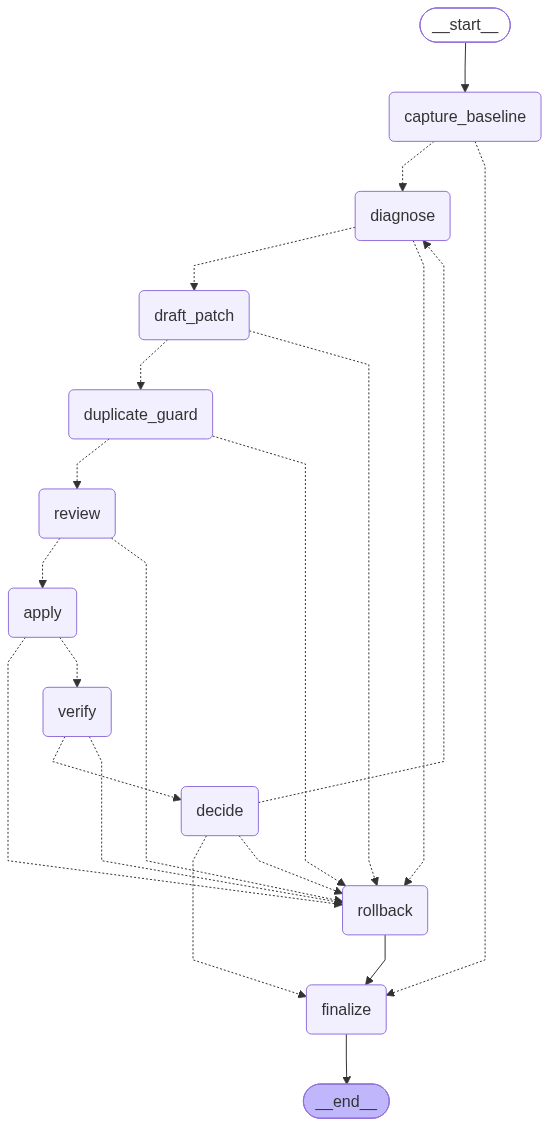

In [16]:
def build_self_heal_graph():
    # StateGraph declares the shared-state shape; registering nodes does not run them.
    builder = StateGraph(GraphState)
    # Stable node names make transaction stages visible in diagrams and traces.
    builder.add_node("capture_baseline", capture_baseline)
    builder.add_node("diagnose", diagnose)
    builder.add_node("draft_patch", draft_patch)
    builder.add_node("duplicate_guard", duplicate_guard)
    builder.add_node("review", review)
    builder.add_node("apply", apply)
    builder.add_node("verify", verify)
    builder.add_node("decide", decide)
    builder.add_node("rollback", rollback)
    builder.add_node("finalize", finalize)

    # START is unconditional. Each route function returns a name that its mapping
    # translates into the next node.
    builder.add_edge(START, "capture_baseline")
    builder.add_conditional_edges(
        "capture_baseline",
        route_after_capture,
        {"diagnose": "diagnose", "finalize": "finalize"},
    )
    builder.add_conditional_edges(
        "diagnose",
        route_after_diagnose,
        {"draft_patch": "draft_patch", "rollback": "rollback"},
    )
    builder.add_conditional_edges(
        "draft_patch",
        route_after_draft,
        {"duplicate_guard": "duplicate_guard", "rollback": "rollback"},
    )
    builder.add_conditional_edges(
        "duplicate_guard",
        route_after_duplicate,
        {"review": "review", "rollback": "rollback"},
    )
    builder.add_conditional_edges(
        "review",
        route_after_review,
        {"apply": "apply", "rollback": "rollback"},
    )
    builder.add_conditional_edges(
        "apply",
        route_after_apply,
        {"verify": "verify", "rollback": "rollback"},
    )
    builder.add_conditional_edges(
        "verify",
        route_after_verify,
        {"decide": "decide", "rollback": "rollback"},
    )
    builder.add_conditional_edges(
        "decide",
        route_after_decide,
        {
            "finalize": "finalize",
            "diagnose": "diagnose",
            "rollback": "rollback",
        },
    )
    # Rollback always finalizes, finalize reaches END, and compile enables .invoke().
    builder.add_edge("rollback", "finalize")
    builder.add_edge("finalize", END)
    return builder.compile()


graph = build_self_heal_graph()
GRAPH_ALT = "Self-Heal transaction with bounded repair loop and compensation path"
# Capture PNG display data or the offline ASCII fallback for replay below.
with capture_output() as _graph_capture:
    show_graph(graph, alt=GRAPH_ALT)
_graph_png = next(
    (
        output.data["image/png"]
        for output in _graph_capture.outputs
        if "image/png" in output.data
    ),
    None,
)
if _graph_png is None:
    # The offline fallback is ordinary stdout, which capture_output stored.
    # Replay it so readers still see the graph instead of a StopIteration error.
    print(_graph_capture.stdout, end="")
else:
    display(
        HTML(
            f'<img alt="{html.escape(GRAPH_ALT)}" '
            f'src="data:image/png;base64,{_graph_png}" />'
        )
    )


## Deterministic scenarios

Each run gets a fresh runtime and mutable workspace. The graph checks the locked scenario record, then compares the complete ten-field record with another fresh runtime executed by the sealed `SelfHealLoop` core. The notebook prints only a compact matrix; `show_record(name)` is available when you intentionally want one complete public record while debugging.


In [17]:
# Give every scenario a fresh runtime and workspace so mutations cannot leak
# from one example into the next.
langgraph_records = []
for scenario_name in SCENARIO_ORDER:
    runtime = new_runtime(scenario_name)
    # invoke starts one complete transaction from the caller-supplied state.
    final_state = graph.invoke(
        {
            "runtime": runtime,
            "initial_failure": runtime.scenario.initial_failure,
            "diagnose_role": runtime.diagnose,
            "draft_role": runtime.fix,
        },
        {"recursion_limit": 64},
    )
    # Validate all ten public fields, not only the compact matrix shown below.
    record = trace_record(scenario_name, final_state["trace"])
    assert_expected_record(record)
    # Run the sealed core on another fresh runtime and require exact record parity.
    core_record = trace_record(
        scenario_name,
        run_core_reference(scenario_name)[0],
    )
    assert record == core_record
    langgraph_records.append(record)

assert [record["scenario"] for record in langgraph_records] == list(SCENARIO_ORDER)


def _record_named(scenario_name: str) -> dict[str, object]:
    try:
        return next(
            record
            for record in langgraph_records
            if record["scenario"] == scenario_name
        )
    except StopIteration:
        raise ValueError(f"unknown executed scenario: {scenario_name}") from None


# Full JSON stays opt-in so the default notebook output remains focused.
def show_record(scenario_name: str) -> None:
    """Opt in to one complete public record when debugging."""
    print(
        json.dumps(
            _record_named(scenario_name),
            ensure_ascii=False,
            indent=2,
            sort_keys=True,
        )
    )


print(format_scenario_matrix(langgraph_records))


scenario          status                         apply  verify  rollback     restored  reason
----------------  -----------------------------  -----  ------  -----------  --------  ----------------------------------
convergence       fixed                          2      2       -            -         verification_passed
critic_block      blocked_by_critic              1      1       c1           yes       review_rejected
no_progress       rolled_back_no_progress        1      1       c1           yes       no_progress_same_failure_and_patch
regression        rolled_back_regression         2      2       c2 -> c1     yes       blast_radius_exceeded
round_budget      max_rounds_human_handoff       2      2       c2 -> c1     yes       round_budget_exhausted
stage_error       stage_error_human_handoff      1      0       c1           yes       stage_error:verify
rollback_failure  rollback_failed_human_handoff  1      1       c1 (failed)  no        review_rejected


### What the matrix proves

- Convergence is the only scenario that leaves repaired state committed.
- Five of the six non-success scenarios prove restoration of the baseline.
- Rollback failure becomes human handoff because restoration cannot be proven.


### Walkthrough: convergence

Follow the two apply and verification receipts to see a second-round repair become the only committed success.


In [18]:
print(format_scenario_walkthrough(_record_named("convergence")))

scenario: convergence
outcome: fixed (verification_passed)
round 1: apply c1 patch dda1f6b5; verification failed e7e8a9de
round 2: apply c2 patch f3926b7d; verification passed
baseline restored: -


### Walkthrough: no progress

The second round repeats the same failure-and-patch pair, so the duplicate guard stops before another apply and compensation restores the baseline.


In [19]:
print(format_scenario_walkthrough(_record_named("no_progress")))

scenario: no_progress
outcome: rolled_back_no_progress (no_progress_same_failure_and_patch)
round 1: apply c1 patch 7bbc2763; verification failed 1e0be10a
rollback c1: succeeded
baseline restored: yes


### Walkthrough: rollback failure

The repair does not converge, and one failed rollback receipt means restoration cannot be proved.


In [20]:
print(format_scenario_walkthrough(_record_named("rollback_failure")))

scenario: rollback_failure
outcome: rollback_failed_human_handoff (review_rejected)
round 1: apply c1 patch bd0a4ab7; verification failed c924ae82
rollback c1: failed
baseline restored: no


In [21]:
print(
    f"{len(langgraph_records)} scenarios matched the sealed core "
    f"across all {len(RECORD_FIELDS)} public fields"
)


7 scenarios matched the sealed core across all 10 public fields


## Optional real model

Only diagnosis and patch drafting cross the model boundary. The provider returns schema-bound values; deterministic code still owns review, apply, verification, rollback, stability, and terminal status.

### Response schemas

These Pydantic models describe the only provider response shapes accepted by the adapter.


In [22]:
# These schemas validate provider response shape; they neither approve a patch
# nor grant permission to mutate workspace state.
class DiagnosisOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    diagnosis: str = Field(
        min_length=1,
        description="One concise diagnosis of the deterministic failure",
    )


# Keep replacements under payload.set to match the strict patch contract.
class PatchPayload(BaseModel):
    model_config = ConfigDict(extra="forbid")

    set: dict[str, str] = Field(
        min_length=1,
        description="Nonempty map of canonical relative paths to replacement text",
    )


# Shape validation happens here; parse_patch_json later enforces canonical paths
# and exact agreement between touches and payload keys.
class PatchOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    description: str = Field(min_length=1, description="Patch intent")
    payload: PatchPayload = Field(
        description='Structured payload containing exactly one "set" object',
    )
    touches: list[str] = Field(
        min_length=1,
        description="Canonical relative POSIX paths matching payload keys exactly",
    )

### Parse schema output through the strict shared boundary

Provider parsing errors are reduced to schema-only messages. Raw provider text and invalid paths never enter `StageError` or saved notebook output. The nested `payload.set` object is serialized locally, then the existing strict parser remains authoritative.


In [23]:
# Invariant: provider-controlled errors never cross this schema-only boundary.
def _parsed_structured(result: dict[str, object], schema):
    # The adapter result may contain raw, parsed, and parsing_error entries; only
    # the validated parsed value may leave this helper.
    parsing_error = result.get("parsing_error")
    if parsing_error is not None:
        raise ValueError(f"{schema.__name__} structured parsing failed") from None
    parsed = result.get("parsed")
    if not isinstance(parsed, schema):
        raise TypeError(f"expected parsed {schema.__name__}") from None
    return parsed


# Re-serialize the Pydantic value so the shared strict parser stays authoritative.
def parse_structured_diagnosis(result: dict[str, object]) -> str:
    parsed = _parsed_structured(result, DiagnosisOutput)
    try:
        return parse_diagnosis_json(parsed.model_dump_json())
    except (TypeError, ValueError):
        raise ValueError("DiagnosisOutput strict validation failed") from None


def parse_structured_patch(result: dict[str, object]) -> Patch:
    parsed = _parsed_structured(result, PatchOutput)
    # Rebuild JSON from parsed fields locally; never forward raw provider text.
    payload = json.dumps(
        {"set": parsed.payload.set},
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )
    raw = json.dumps(
        {
            "description": parsed.description,
            "payload": payload,
            "touches": parsed.touches,
        },
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )
    try:
        # The shared parser enforces canonical paths and payload/touches agreement.
        return parse_patch_json(raw)
    except (TypeError, ValueError):
        raise ValueError("PatchOutput strict validation failed") from None

### Bind schemas to the provider model

`include_raw=True` keeps the raw response transiently available to the provider adapter, while the notebook saves only bounded summaries.


In [24]:
# include_raw=True asks the model adapter for a raw/parsed/parsing_error envelope;
# the strict adapters inspect errors but never expose raw provider content.
def build_structured_role_models(model):
    return (
        model.with_structured_output(
            DiagnosisOutput, method="json_schema", include_raw=True
        ),
        model.with_structured_output(
            PatchOutput, method="json_schema", include_raw=True
        ),
    )


# Prompts request diagnosis and patch proposals, never transaction decisions.
DIAGNOSIS_SYSTEM_PROMPT = (
    "You diagnose a deterministic CI failure.\n"
    "Return one concise diagnosis through the supplied response schema."
)

PATCH_SYSTEM_PROMPT = (
    "You draft one atomic patch from a diagnosis.\n"
    "Use the supplied response schema with one nested payload.set object; "
    "payload paths and touches must match exactly."
)


### Run the same graph with model roles

`get_model()` returns `None` and prints one skip line when the configured provider has no API key. On a live run, only clipped diagnosis, patch, terminal result, and one deterministic review reason or evidence item are displayed; the complete trace remains available in `model_state` for deliberate inspection.


In [25]:
# Missing credentials return None, so the same notebook remains runnable offline.
model = get_model()

if model is not None:
    diagnosis_model, patch_model = build_structured_role_models(model)

    # The model receives failure facts and may return diagnosis content only.
    def model_diagnose(failure: FailureSignal) -> str:
        result = diagnosis_model.invoke(
            [
                SystemMessage(content=DIAGNOSIS_SYSTEM_PROMPT),
                HumanMessage(
                    content=json.dumps(
                        {
                            "kind": failure.kind,
                            "error_text": failure.error_text,
                            "affected_files": failure.affected_files,
                            "code": failure.code,
                        }
                    )
                ),
            ]
        )
        return parse_structured_diagnosis(result)

    # Drafting receives the diagnosis and returns a proposal; it never applies it.
    def model_draft(diagnosis: str) -> Patch:
        result = patch_model.invoke(
            [
                SystemMessage(content=PATCH_SYSTEM_PROMPT),
                HumanMessage(content=diagnosis),
            ]
        )
        return parse_structured_patch(result)

    # The unchanged graph still owns review, mutation, verification, and rollback.
    model_runtime = new_runtime("convergence")
    model_state = graph.invoke(
        {
            "runtime": model_runtime,
            "initial_failure": model_runtime.scenario.initial_failure,
            "diagnose_role": model_diagnose,
            "draft_role": model_draft,
        },
        {"recursion_limit": 64},
    )

    # Bound saved provider text so the teaching result stays compact and skimmable.
    def _clip_summary(value: object, limit: int = 160) -> str:
        text = " ".join(str(value).split())
        return text if len(text) <= limit else f"{text[: limit - 3]}..."


    live_trace = model_state["trace"]
    live_round = live_trace.rounds[-1] if live_trace.rounds else None
    diagnosis = live_round.diagnosis if live_round is not None else "unavailable"
    print(f"diagnosis: {_clip_summary(diagnosis)}")
    if live_round is not None:
        candidate = live_round.patch
        print(
            "patch: "
            + _clip_summary(
                f"{candidate.description}; files={list(candidate.touches)}"
            )
        )
    print(f"result: {live_trace.status.value} ({live_trace.stop_reason})")

    # Surface the deterministic gate that decided whether the proposal could apply.
    candidate_review = live_round.patch_review if live_round is not None else None
    if candidate_review is None:
        print("review: unavailable; transaction stopped before deterministic review")
    else:
        review_detail = candidate_review.reason.strip() or next(
            (
                item.strip()
                for item in candidate_review.evidence
                if item.strip() and "digest=" not in item
            ),
            "deterministic policy supplied no text detail",
        )
        decision = "approved" if candidate_review.approved else "rejected"
        print(f"review: {decision}; {_clip_summary(review_detail)}")


Model: ernie:glm-5.1


diagnosis: CONVERGENCE_1 failure in app.py: an iterative algorithm or optimization loop failed to converge within the expected iteration limit or tolerance threshold. T...
patch: Fix CONVERGENCE_1: add abs() to convergence check so that small-magnitude differences of either sign are correctly detected as converged. Without abs(), a ne...
result: blocked_by_critic (review_rejected)
review: rejected; patch content does not satisfy the current failure


### Compose as a subgraph

The compiled graph is a normal LangGraph runnable. A parent workflow can place it behind a deterministic failure detector and inspect `trace.status` before deciding whether to continue, ask a human, or halt deployment. The parent should pass fresh role callables and runtime state for each repair transaction.

```python
parent = StateGraph(DeploymentState)
parent.add_node("detect_failure", detect_failure)
parent.add_node("self_heal", graph)
parent.add_conditional_edges("detect_failure", route_failure, {
    "repair": "self_heal",
    "healthy": END,
})
```

The same graph shape supports deterministic fixtures and real model roles because policy authority never moves into the model.


## What to remember

- Self-Heal is a bounded transaction, not an open-ended autonomous retry loop.
- Models may diagnose and draft; deterministic callbacks own review, mutation, verification, rollback, and status.
- A duplicate `(failure.signature, patch.digest)` proves no progress before another mutation occurs.
- Addressable apply receipts are retained even when their binding is invalid, so compensation can still run.
- Restoration is a proof: every known apply must have a valid rollback receipt, no mutation may be unaddressable, and the final digest must equal the baseline.
- The seven executed graph records match fresh sealed-core records across all ten public fields.


## Further reading

- [LangChain tutorial](../langchain/tutorial.ipynb) — the same transaction contract expressed with LCEL stages
- [Pattern README](../README.md) — design rationale and framework-neutral public contract
- [Reference implementation guide](../../../REFERENCE_IMPL.md) — repository conventions and verification commands
- [LangGraph `StateGraph` reference](https://docs.langchain.com/oss/python/langgraph/graph-api)
